# Lab 11: Diabetes Clustering Example

This example will use the diabetes dataset from [scikit-learn](https://scikit-learn.org/1.5/modules/generated/sklearn.datasets.load_diabetes.html). This dataset includes age, sex, body mass index (BMI), average blood pressure, and six blood serum measurements, obtained from 442 diabetes patients. The target variable is a quantitative measure of disease progression one year after baseline measurements (regression).

We might want to cluster this data to be able to predict what the outcome might be for a new patient, based on their similarity to existing patient data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

First, we need to load the dataset. In this case, we only want the feature matrix.

In [3]:
# Note that the default data is scaled
from sklearn.datasets import load_diabetes
df, _ = load_diabetes(return_X_y=True, as_frame=True, scaled=False)
df = df[['age', 'sex', 'bmi', 'bp']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
dtypes: float64(4)
memory usage: 13.9 KB


In [4]:
df.describe()

,age,sex,bmi,bp
count,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014
std,13.109028,0.499561,4.418122,13.831283
min,19.000000,1.000000,18.000000,62.000000
25%,38.250000,1.000000,23.200000,84.000000
50%,50.000000,1.000000,25.700000,93.000000
75%,59.000000,2.000000,29.275000,105.000000
max,79.000000,2.000000,42.200000,133.000000


In [10]:
df['sex'].value_counts()

sex
1.0    235
2.0    207
Name: count, dtype: int64

## K-means clustering
There are a few questions that we must answer before we start clustering:

1. Do we need to process the data first?
1. How many clusters should we use?
1. Which method should we use?

### Preprocessing

In [5]:
from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()

scaler = StandardScaler()
scaler.fit(df_scaled)
df_scaled = pd.DataFrame(scaler.transform(df_scaled), columns=df_scaled.columns)
df_scaled.describe()

,age,sex,bmi,bp
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,8.037814e-18,1.607563e-16,1.004727e-16,1.060991e-15
std,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00
min,-2.254290e+00,-9.385367e-01,-1.897929e+00,-2.363050e+00
25%,-7.841722e-01,-9.385367e-01,-7.196249e-01,-7.706500e-01
50%,1.131724e-01,-9.385367e-01,-1.531324e-01,-1.192138e-01
75%,8.005001e-01,1.065488e+00,6.569519e-01,7.493678e-01
max,2.327895e+00,1.065488e+00,3.585718e+00,2.776058e+00


### Check Number of Clusters

We can use the elbow method to determine the number of clusters:

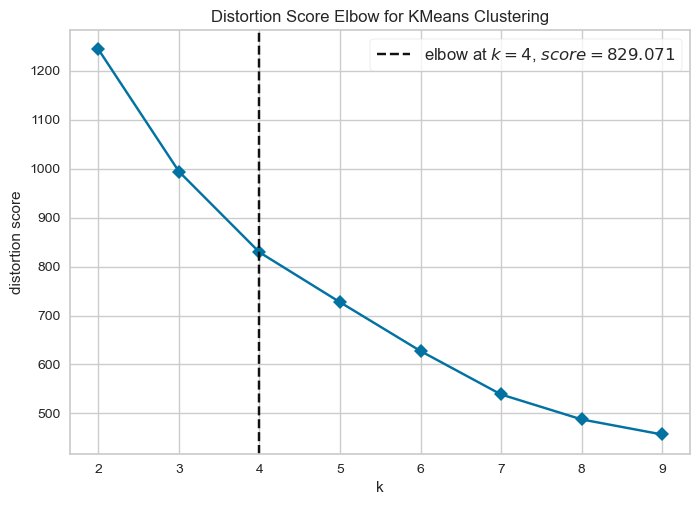

KElbowVisualizer(ax=<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>,
                 estimator=KMeans(n_clusters=9, random_state=54), k=(2, 10),
                 timings=False)

In [6]:
from yellowbrick.cluster.elbow import kelbow_visualizer
from sklearn.cluster import KMeans

kelbow_visualizer(KMeans(random_state=54), df_scaled, k=(2,10), 
                  metric='distortion',
                 timings=False)

In [7]:
kmeans = KMeans(n_clusters=4, random_state=54)
kmeans.fit(df_scaled)

centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_scaled.columns)
centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=df_scaled.columns)

df['clusters'] = kmeans.labels_
df['clusters'] = df['clusters'].astype('category') #makes seaborn use qualitative color palette

In [8]:
df.dtypes

age          float64
sex          float64
bmi          float64
bp           float64
clusters    category
dtype: object

## Visualization

Counter({3: 126, 2: 109, 1: 109, 0: 98})


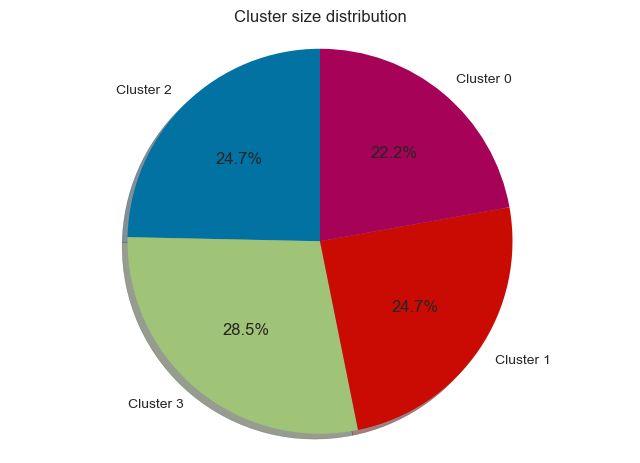

In [9]:
from collections import Counter
counts = Counter(kmeans.labels_)
print(counts)
fig1, ax1 = plt.subplots()
ax1.pie(counts.values(), labels=[f'Cluster {i}' for i in counts.keys()], autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal');  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1.set_title('Cluster size distribution');

**Note:** Clusters are somewhat balanced.

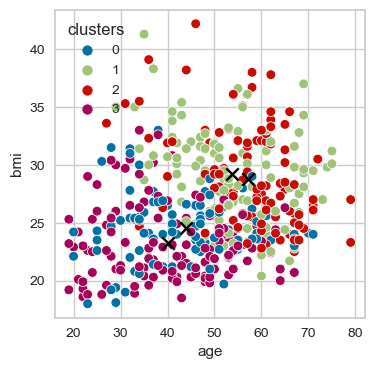

In [11]:
fig, ax = plt.subplots(figsize=(4,4))
ax = sns.scatterplot(x='age', y='bmi', hue='clusters', ax=ax, data=df)

centers.plot.scatter(x='age', y='bmi', ax=ax, marker='x', s=80, color='black');

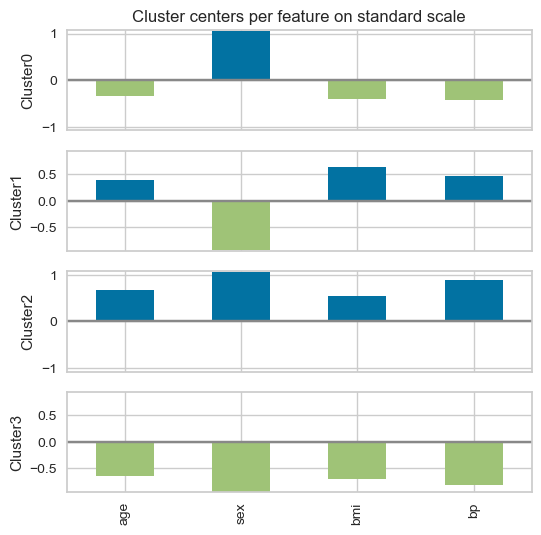

In [12]:
f, axes = plt.subplots(kmeans.n_clusters, 1, figsize=(6, 6), sharex=True)

for i, ax in enumerate(axes):
    center = centers_scaled.loc[i, :]
    maxPC = 1.01 * np.max(np.max(np.abs(center)))
    colors = ['C0' if l>0 else 'C1' for l in center]
    ax.axhline(color='#888888')
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'Cluster{i}')
    ax.set_ylim(-maxPC, maxPC)
    if i == 0:
        ax.set_title('Cluster centers per feature on standard scale')


In the plot above, _Cluster 0_ contains average age patients with low bmi and low bp; _Cluster 1_ on the other hand contains patients with average age above average -> older individuals who have high bmi and high bp. _Cluster 2_ is similar to _Cluster 1_ but for the opposite gender, with a slightly higher average age and bp; _Cluster 3_ has patients with age well below the average -> young individuals who have low bmi and low bp.

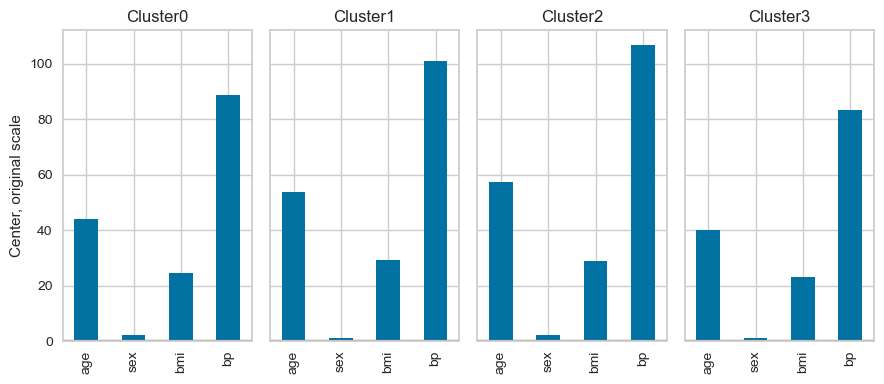

In [13]:
f, axes = plt.subplots(1, kmeans.n_clusters, figsize=(9, 4), sharey=True)

overall_max = centers.max().max()

for i, ax in enumerate(axes):
    center = centers.loc[i, :]
    colors = ['C0' if l>0 else 'C1' for l in center]
    ax.axhline(color='#888888')
    center.plot.bar(ax=ax, color=colors)
    ax.set_title(f'Cluster{i}')
    if i == 0:
        ax.set_ylabel('Center, original scale')

plt.tight_layout()

## Validation

We can use the silhouette score and the calinski_harabasz score to verify our results:

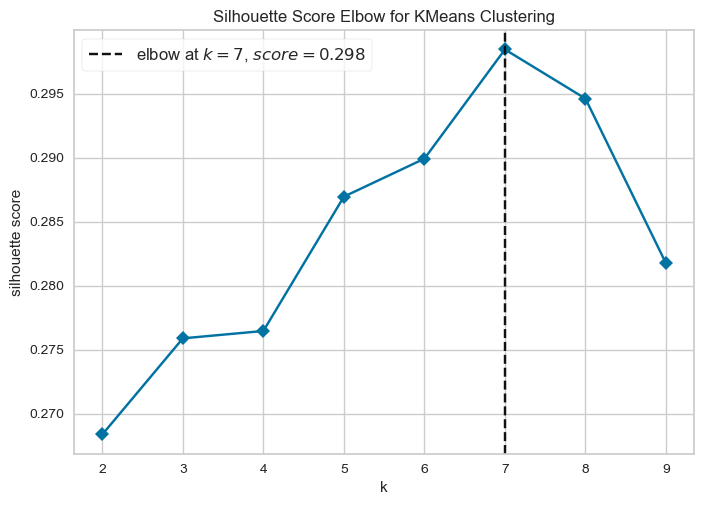

KElbowVisualizer(ax=<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>,
                 estimator=KMeans(n_clusters=9, random_state=54), k=(2, 10),
                 metric='silhouette', timings=False)

In [14]:
kelbow_visualizer(KMeans(random_state=54), df_scaled, k=(2,10), 
                  metric='silhouette',
                 timings=False)

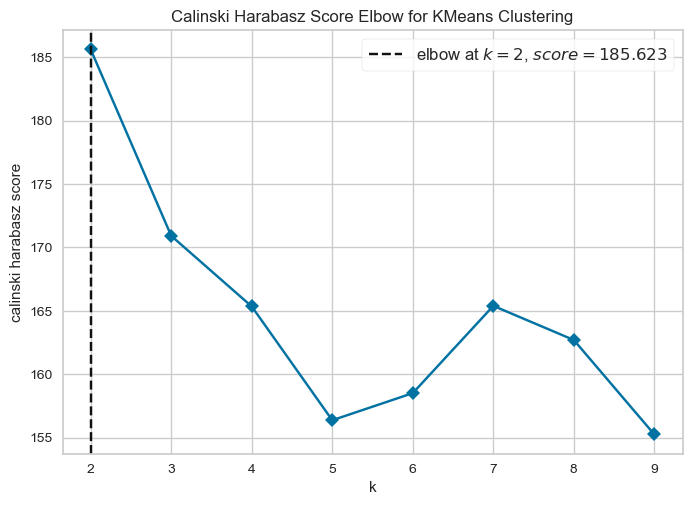

KElbowVisualizer(ax=<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>,
                 estimator=KMeans(n_clusters=9, random_state=54), k=(2, 10),
                 metric='calinski_harabasz', timings=False)

In [15]:
kelbow_visualizer(KMeans(random_state=54), df_scaled, k=(2,10), 
                  metric='calinski_harabasz',
                 timings=False)